# Fashion MNIST: Visualization Examples



## 0. Setup



In [1]:
import gzip
import urllib.request
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100
%matplotlib inline

CLASS_NAMES = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


### Download & parse the raw IDX files with NumPy

In [2]:
BASE_URL = "https://raw.githubusercontent.com/zalandoresearch/fashion-mnist/master/data/fashion/"

def fetch(filename):
    """Download a file if not already cached locally."""
    path = f"/tmp/{filename}"
    try:
        with open(path, 'rb') as f:
            return f.read()
    except FileNotFoundError:
        with urllib.request.urlopen(BASE_URL + filename) as resp:
            data = resp.read()
        with open(path, 'wb') as f:
            f.write(data)
        return data

def load_images(filename):
    raw = gzip.decompress(fetch(filename))
    n = int.from_bytes(raw[4:8], 'big')
    rows = int.from_bytes(raw[8:12], 'big')
    cols = int.from_bytes(raw[12:16], 'big')
    return np.frombuffer(raw, dtype=np.uint8, offset=16).reshape(n, rows, cols)

def load_labels(filename):
    raw = gzip.decompress(fetch(filename))
    return np.frombuffer(raw, dtype=np.uint8, offset=8)

X_train = load_images('train-images-idx3-ubyte.gz')
y_train = load_labels('train-labels-idx1-ubyte.gz')

print("Images:", X_train.shape)   # (60000, 28, 28)
print("Labels:", y_train.shape)   # (60000,)
print("Pixel value range:", X_train.min(), "-", X_train.max())


Images: (60000, 28, 28)
Labels: (60000,)
Pixel value range: 0 - 255


### Load into a pandas DataFrame

Each 28x28 image is flattened into 784 pixel columns, one row per image — the standard tabular representation for this kind of data.

In [3]:
n_samples = 60000  # subsample for speed; UMAP/plotting all 60,000 isn't necessary for this demo

rng = np.random.default_rng(42)
idx = rng.choice(len(X_train), size=n_samples, replace=False)

X_sample = X_train[idx]
y_sample = y_train[idx]

pixel_cols = [f'pixel_{i}' for i in range(784)]
df = pd.DataFrame(X_sample.reshape(n_samples, -1), columns=pixel_cols)
df['label'] = y_sample
df['category'] = df['label'].map(dict(enumerate(CLASS_NAMES)))

print(df.shape)
df[['label', 'category'] + pixel_cols[:5]].head()


(60000, 786)


,label,category,pixel_0,pixel_1,pixel_2,pixel_3,pixel_4
0,7,Sneaker,0,0,0,0,0
1,8,Bag,0,0,0,0,0
2,8,Bag,0,0,0,0,0
3,8,Bag,0,0,0,0,0
4,1,Trouser,0,0,0,0,0


### Quick look: one example image per category

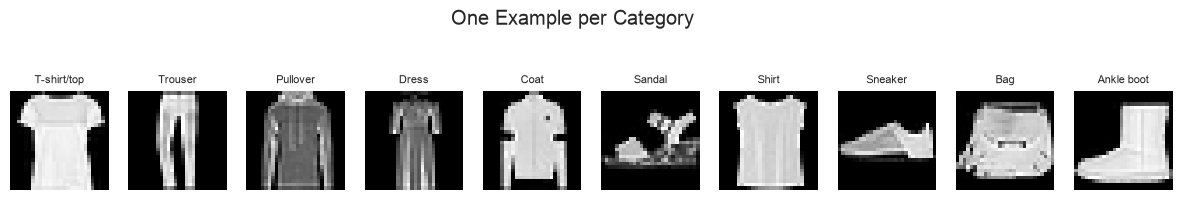

In [4]:
fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for class_id, ax in enumerate(axes):
    example = X_sample[y_sample == class_id][0]
    ax.imshow(example, cmap='gray')
    ax.set_title(CLASS_NAMES[class_id], fontsize=8)
    ax.axis('off')
plt.suptitle('One Example per Category', y=1.15)
plt.show()
